# 02 — Manual MPC: From QP to Closed Loop

Chapter 3 derived the finite-horizon MPC problem.  
This notebook implements it manually:

$$
X = \Phi x_0 + \Gamma U,
\qquad
J_N(U)=U^\top H U + 2h(x_0)^\top U + \text{constant}.
$$

CasADi is not used here. The goal is to see the matrices that the QP solver receives.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import osqp
from scipy.linalg import solve_discrete_are, block_diag

np.set_printoptions(precision=4, suppress=True)

## Plotting helpers

The plots are support material. The MPC construction below should stay visible and readable.

In [2]:
def plot_scalar_qp(u_grid, J_grid, u_unconstrained, u_constrained, u_max):
    plt.figure(figsize=(7, 4))
    plt.plot(u_grid, J_grid, label=r"$J(u)$")
    plt.axvline(u_unconstrained, linestyle="--", label="unconstrained optimum")
    plt.axvline(u_constrained, linestyle="--", label="constrained optimum")
    plt.axvline(u_max, color="k", linestyle=":", linewidth=1.0)
    plt.axvline(-u_max, color="k", linestyle=":", linewidth=1.0, label="feasible interval")
    plt.xlabel(r"$u$")
    plt.ylabel(r"$J(u)$")
    plt.title("One-dimensional constrained QP")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


def plot_plan(X_plan, U_plan, x_max, v_max, u_max, title):
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))

    ax[0].plot(X_plan[:, 0], "o-", label="position")
    ax[0].axhline(x_max, linestyle=":", color="r")
    ax[0].axhline(-x_max, linestyle=":", color="r")
    ax[0].set_title("Predicted position")
    ax[0].set_xlabel(r"prediction index $i$")
    ax[0].grid(True, alpha=0.3)
    ax[0].legend()

    ax[1].plot(X_plan[:, 1], "o-", label="velocity")
    ax[1].axhline(v_max, linestyle=":", color="r")
    ax[1].axhline(-v_max, linestyle=":", color="r")
    ax[1].set_title("Predicted velocity")
    ax[1].set_xlabel(r"prediction index $i$")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend()

    ax[2].step(range(len(U_plan)), U_plan[:, 0], where="post", label="input")
    ax[2].axhline(u_max, linestyle=":", color="r")
    ax[2].axhline(-u_max, linestyle=":", color="r")
    ax[2].set_title("Predicted input")
    ax[2].set_xlabel(r"prediction index $i$")
    ax[2].grid(True, alpha=0.3)
    ax[2].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_closed_loop(X_hist, U_hist, x_max, v_max, u_max, title):
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))

    ax[0].plot(X_hist[:, 0], "o-", label="position")
    ax[0].axhline(x_max, linestyle=":", color="r")
    ax[0].axhline(-x_max, linestyle=":", color="r")
    ax[0].set_title("Closed-loop position")
    ax[0].set_xlabel(r"time step $k$")
    ax[0].grid(True, alpha=0.3)
    ax[0].legend()

    ax[1].plot(X_hist[:, 1], "o-", label="velocity")
    ax[1].axhline(v_max, linestyle=":", color="r")
    ax[1].axhline(-v_max, linestyle=":", color="r")
    ax[1].set_title("Closed-loop velocity")
    ax[1].set_xlabel(r"time step $k$")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend()

    ax[2].step(range(len(U_hist)), U_hist[:, 0], where="post", label="input")
    ax[2].axhline(u_max, linestyle=":", color="r")
    ax[2].axhline(-u_max, linestyle=":", color="r")
    ax[2].set_title("Closed-loop input")
    ax[2].set_xlabel(r"time step $k$")
    ax[2].grid(True, alpha=0.3)
    ax[2].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_controller_comparison(results, x_max, v_max, u_max):
    fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
    for label, (X_hist, U_hist) in results.items():
        ax[0].plot(X_hist[:, 0], label=label)
        ax[1].plot(X_hist[:, 1], label=label)
        ax[2].step(range(len(U_hist)), U_hist[:, 0], where="post", label=label)

    ax[0].axhline(x_max, linestyle=":", color="k", linewidth=0.8)
    ax[0].axhline(-x_max, linestyle=":", color="k", linewidth=0.8)
    ax[0].set_title("Position")
    ax[0].set_xlabel(r"$k$")
    ax[0].grid(True, alpha=0.3)
    ax[0].legend()

    ax[1].axhline(v_max, linestyle=":", color="k", linewidth=0.8)
    ax[1].axhline(-v_max, linestyle=":", color="k", linewidth=0.8)
    ax[1].set_title("Velocity")
    ax[1].set_xlabel(r"$k$")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend()

    ax[2].axhline(u_max, linestyle=":", color="k", linewidth=0.8)
    ax[2].axhline(-u_max, linestyle=":", color="k", linewidth=0.8)
    ax[2].set_title("Input")
    ax[2].set_xlabel(r"$k$")
    ax[2].grid(True, alpha=0.3)
    ax[2].legend()

    plt.tight_layout()
    plt.show()

## 1) A tiny QP: how the solver is called

OSQP, the solver we choose, solves problems in the form

$$
\min_z \frac12 z^\top Pz + q^\top z
\qquad \text{s.t.} \qquad Az \le b .
$$

We start with one scalar problem:

$$
\min_u \; r u^2 + \alpha(x_0+u)^2
\qquad \text{s.t.} \qquad |u|\le u_{\max} .
$$

unconstrained optimum: -3.6364
constrained optimum:   -1.0000


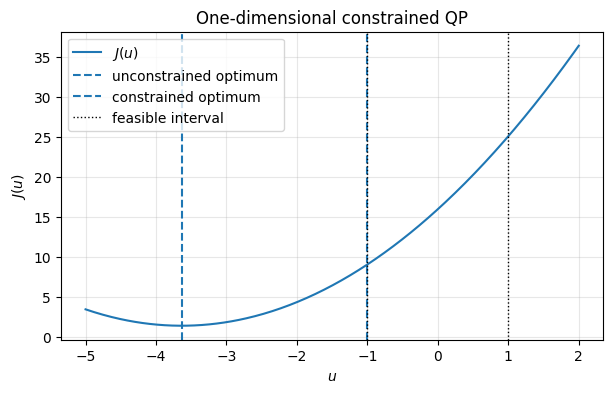

In [3]:
def solve_qp_osqp(P, q, A_ineq, b_ineq):
    # Solve min 0.5 z.T P z + q.T z subject to A_ineq z <= b_ineq.
    P = np.asarray(P, dtype=float)
    q = np.asarray(q, dtype=float).reshape(-1)
    A_ineq = np.asarray(A_ineq, dtype=float)
    b_ineq = np.asarray(b_ineq, dtype=float).reshape(-1)

    # Numerical solvers expect a symmetric Hessian.
    P = 0.5 * (P + P.T)

    solver = osqp.OSQP()
    solver.setup(
        P=sp.csc_matrix(P),
        q=q,
        A=sp.csc_matrix(A_ineq),
        l=-np.inf * np.ones(A_ineq.shape[0]),
        u=b_ineq,
        verbose=False,
        polish=True,
        eps_abs=1e-9,
        eps_rel=1e-9,
    )
    result = solver.solve()
    if result.info.status != "solved":
        raise RuntimeError(f"OSQP failed with status: {result.info.status}")
    return result.x, result.info


x0_scalar = 4.0
r_scalar = 0.1
alpha = 1.0
u_max_scalar = 1.0

# J(u) = r*u^2 + alpha*(x0 + u)^2
# Solver form: 0.5*P*u^2 + q*u + constant
P_demo = np.array([[2.0 * (r_scalar + alpha)]])
q_demo = np.array([2.0 * alpha * x0_scalar])
A_demo = np.array([[1.0], [-1.0]])
b_demo = np.array([u_max_scalar, u_max_scalar])

u_demo, _ = solve_qp_osqp(P_demo, q_demo, A_demo, b_demo)
u_demo = float(u_demo[0])

u_unconstrained = -alpha * x0_scalar / (r_scalar + alpha)
print(f"unconstrained optimum: {u_unconstrained:+.4f}")
print(f"constrained optimum:   {u_demo:+.4f}")

u_grid = np.linspace(-5.0, 2.0, 400)
J_grid = r_scalar * u_grid**2 + alpha * (x0_scalar + u_grid)**2
plot_scalar_qp(u_grid, J_grid, u_unconstrained, u_demo, u_max_scalar)

## 2) Double-integrator benchmark

We use the same benchmark as in the lecture:

$$
x_{k+1}=Ax_k+Bu_k,
\qquad
x = \begin{bmatrix}\text{position}\\ \text{velocity}\end{bmatrix}.
$$

The terminal weight is chosen as

$$
P_f=P_\infty,
$$

the LQR cost-to-go matrix of the unconstrained problem.

In [4]:
A = np.array([[1.0, 1.0],
              [0.0, 1.0]])
B = np.array([[0.0],
              [1.0]])

Q = np.diag([4.0, 1.0])
R = np.array([[0.2]])

P_inf = solve_discrete_are(A, B, Q, R)
K_inf = np.linalg.solve(R + B.T @ P_inf @ B, B.T @ P_inf @ A)

N = 10
P_f = P_inf.copy()

x_max = 4.8
v_max = 2.5
u_max = 0.8

nx = A.shape[0]
nu = B.shape[1]

x0 = np.array([3.2, 1.2])

print("P_inf =")
print(P_inf)
print("K_inf =")
print(K_inf)

P_inf =
[[9.0385 5.1926]
 [5.1926 6.5407]]
K_inf =
[[0.7703 1.7407]]


## 3) Prediction matrices

The condensed prediction model is

$$
X = \Phi x_0 + \Gamma U,
$$

with

$$
X = \begin{bmatrix}x_1\\x_2\\ \vdots \\ x_N\end{bmatrix},
\qquad
U = \begin{bmatrix}u_0\\u_1\\ \vdots \\ u_{N-1}\end{bmatrix}.
$$

In [5]:
def build_prediction_matrices(A, B, N):
    # Build Phi and Gamma for X = Phi*x0 + Gamma*U.
    nx = A.shape[0]
    nu = B.shape[1]

    Phi = np.zeros((nx * N, nx))
    Gamma = np.zeros((nx * N, nu * N))

    for i in range(1, N + 1):
        Phi[(i - 1) * nx : i * nx, :] = np.linalg.matrix_power(A, i)

        for j in range(i):
            Gamma[(i - 1) * nx : i * nx, j * nu : (j + 1) * nu] = (
                np.linalg.matrix_power(A, i - 1 - j) @ B
            )

    return Phi, Gamma


Phi, Gamma = build_prediction_matrices(A, B, N)

print("Phi shape:", Phi.shape)
print("Gamma shape:", Gamma.shape)

Phi_demo, Gamma_demo = build_prediction_matrices(A, B, N=3)
print("\nPhi for N = 3:")
print(Phi_demo)
print("\nGamma for N = 3:")
print(Gamma_demo)

Phi shape: (20, 2)
Gamma shape: (20, 10)

Phi for N = 3:
[[1. 1.]
 [0. 1.]
 [1. 2.]
 [0. 1.]
 [1. 3.]
 [0. 1.]]

Gamma for N = 3:
[[0. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 1. 0.]
 [2. 1. 0.]
 [1. 1. 1.]]


## 4) Condensed cost

The lecture form is

$$
J_N(U)=U^\top H U+2h(x_0)^\top U+\text{constant}.
$$

For the stacked state vector $X=[x_1,\ldots,x_N]$, use

$$
\bar Q = \operatorname{diag}(Q,\ldots,Q,P_f),
\qquad
\bar R = \operatorname{diag}(R,\ldots,R).
$$

Then

$$
H=\Gamma^\top \bar Q\Gamma+\bar R,
\qquad
h(x_0)=\Gamma^\top \bar Q\Phi x_0.
$$

The stage cost at $x_0$ is constant with respect to $U$, so it does not change the optimizer.

In [6]:
Q_bar = block_diag(*([Q for _ in range(N - 1)] + [P_f]))
R_bar = block_diag(*([R for _ in range(N)]))

H = Gamma.T @ Q_bar @ Gamma + R_bar
h = Gamma.T @ Q_bar @ (Phi @ x0)

print("H shape:", H.shape)
print("h shape:", h.shape)
print("largest Hessian symmetry error:", np.max(np.abs(H - H.T)))

H shape: (10, 10)
h shape: (10,)
largest Hessian symmetry error: 2.2737367544323206e-13


## 5) Unconstrained check: MPC with $P_f=P_\infty$ matches LQR

Without constraints, the optimizer is obtained from

$$
\nabla_U J_N(U)=2HU+2h=0,
\qquad
U^\star=-H^{-1}h.
$$

With $P_f=P_\infty$, the first MPC input equals the infinite-horizon LQR input.

In [7]:
U_unconstrained = -np.linalg.solve(H, h)

u0_mpc = float(U_unconstrained[0])
u0_lqr = float(-(K_inf @ x0).item())

print(f"u0 from unconstrained MPC: {u0_mpc:+.8f}")
print(f"u0 from LQR:               {u0_lqr:+.8f}")
print(f"difference:                {abs(u0_mpc - u0_lqr):.3e}")

u0 from unconstrained MPC: -4.55385125
u0 from LQR:               -4.55385125
difference:                3.828e-13


## 6) Input constraints

The input box

$$
|u_i|\le u_{\max},\qquad i=0,\ldots,N-1
$$

$$
G_u U \le g_u
$$

becomes

$$
\begin{bmatrix}I\\-I\end{bmatrix}U
\le
\begin{bmatrix}u_{\max}\mathbf 1\\u_{\max}\mathbf 1\end{bmatrix}.
$$

first input with input bounds: -0.8000


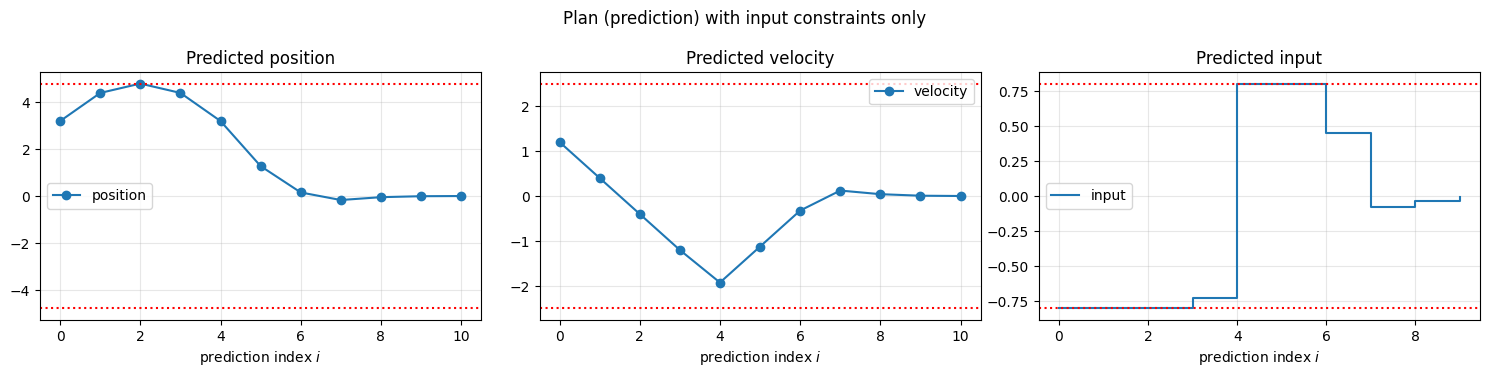

In [8]:
G_u = np.vstack([
    np.eye(nu * N),
    -np.eye(nu * N),
])
g_u = u_max * np.ones(2 * nu * N)

U_input_only, _ = solve_qp_osqp(2.0 * H, 2.0 * h, G_u, g_u)
U_input_only = U_input_only.reshape(N, nu)

# Predicted future states, stacked as [x_1, x_2, ..., x_N]
X_stack_input_only = Phi @ x0 + Gamma @ U_input_only.reshape(-1)

# Reshape to one state per row and prepend the known initial state x_0
X_plan_input_only = np.vstack([x0, X_stack_input_only.reshape(N, nx)])

print(f"first input with input bounds: {U_input_only[0, 0]:+.4f}")
plot_plan(X_plan_input_only, U_input_only, x_max, v_max, u_max, "Plan (prediction) with input constraints only")

## 7) State constraints and one complete MPC solve

We now solve one complete finite-horizon MPC problem for the current state \(x_0\).

The stacked prediction is

$$
X =
\begin{bmatrix}
x_1\\
\vdots\\
x_N
\end{bmatrix}
=
\Phi x_0+\Gamma U,
\qquad
U =
\begin{bmatrix}
u_0\\
\vdots\\
u_{N-1}
\end{bmatrix}.
$$

The condensed cost is

$$
J_N(U)
=
U^\top H U
+
2h(x_0)^\top U
+
\text{constant},
$$

with

$$
\bar Q = \operatorname{diag}(Q,\ldots,Q,P_f),
\qquad
\bar R = \operatorname{diag}(R,\ldots,R),
$$

$$
H = \Gamma^\top \bar Q \Gamma + \bar R,
\qquad
h(x_0)=\Gamma^\top \bar Q \Phi x_0.
$$

The input constraints are

$$
G_u U \le g_u,
\qquad
G_u =
\begin{bmatrix}
I\\
-I
\end{bmatrix},
\qquad
g_u =
u_{\max}\mathbf 1.
$$

The state constraints are first written as

$$
F_x X \le f_x.
$$

Using \(X=\Phi x_0+\Gamma U\), this becomes

$$
G_x U \le g_x,
\qquad
G_x = F_x\Gamma,
\qquad
g_x = f_x - F_x\Phi x_0.
$$

Finally, both constraint blocks are stacked:

$$
G =
\begin{bmatrix}
G_u\\
G_x
\end{bmatrix},
\qquad
g =
\begin{bmatrix}
g_u\\
g_x
\end{bmatrix},
\qquad
GU\le g.
$$

OSQP expects the form

$$
\min_U
\frac12 U^\top P_{\mathrm{osqp}}U
+
q_{\mathrm{osqp}}^\top U
\quad
\text{s.t.}
\quad
GU\le g.
$$

Therefore,

$$
P_{\mathrm{osqp}}=2H,
\qquad
q_{\mathrm{osqp}}=2h(x_0).
$$

The function below follows these equations step by step.

OSQP status: solved
first input applied by MPC: -0.8000
minimum remaining position margin: -0.0000
minimum remaining velocity margin: +0.5765


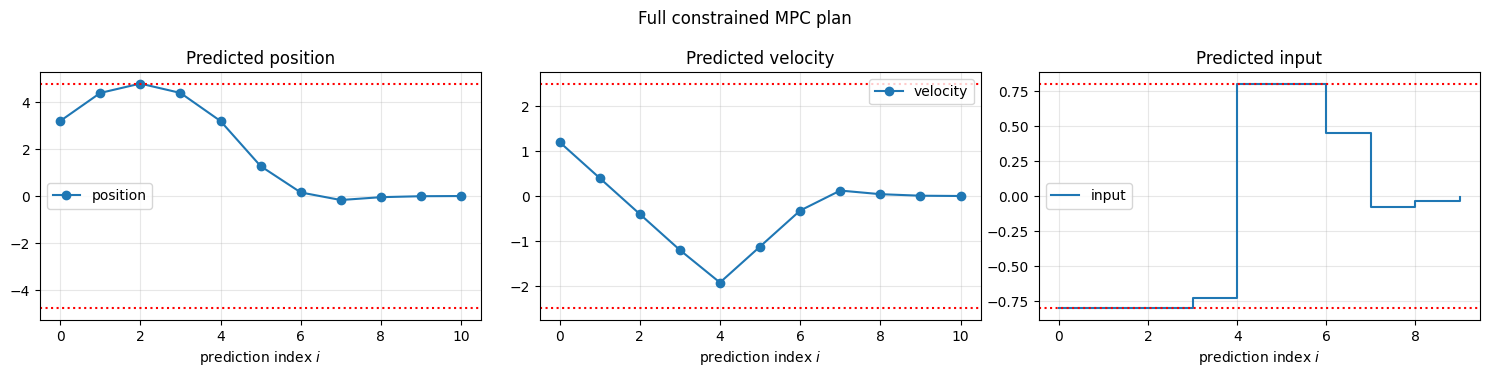

In [9]:
def solve_mpc_once(x0, N=N, Q=Q, R=R, P_f=P_inf):
    # Solve one finite-horizon MPC problem for the current state x0.
    x0 = np.asarray(x0, dtype=float).reshape(nx)

    # 1) Prediction model: X = Phi*x0 + Gamma*U
    Phi, Gamma = build_prediction_matrices(A, B, N)

    # 2) Condensed cost: J = U.T*H*U + 2*h.T*U + constant
    Q_bar = block_diag(*([Q for _ in range(N - 1)] + [P_f]))
    R_bar = block_diag(*([R for _ in range(N)]))
    H = Gamma.T @ Q_bar @ Gamma + R_bar
    h = Gamma.T @ Q_bar @ (Phi @ x0)

    # 3) Input constraints: |u_i| <= u_max
    G_u = np.vstack([
        np.eye(nu * N),
        -np.eye(nu * N),
    ])
    g_u = u_max * np.ones(2 * nu * N)

    # 4) State constraints on X = [x1, ..., xN]
    F_single = np.array([
        [1.0, 0.0],
        [-1.0, 0.0],
        [0.0, 1.0],
        [0.0, -1.0],
    ])
    f_single = np.array([x_max, x_max, v_max, v_max])

    F_x = block_diag(*([F_single] * N))
    f_x = np.tile(f_single, N)

    G_x = F_x @ Gamma
    g_x = f_x - F_x @ (Phi @ x0)

    # 5) Stack inequalities and solve in OSQP form
    G = np.vstack([G_u, G_x])
    g = np.concatenate([g_u, g_x])

    U_star, info = solve_qp_osqp(2.0 * H, 2.0 * h, G, g)

    # 6) Recover the predicted trajectory
    X_stack = Phi @ x0 + Gamma @ U_star
    U_plan = U_star.reshape(N, nu)
    X_plan = np.vstack([x0, X_stack.reshape(N, nx)])

    return U_plan, X_plan, info


U_plan, X_plan, info = solve_mpc_once(x0)

print(f"OSQP status: {info.status}")
print(f"first input applied by MPC: {U_plan[0, 0]:+.4f}")
print(f"minimum remaining position margin: {np.min(x_max - np.abs(X_plan[:, 0])):+.4f}")
print(f"minimum remaining velocity margin: {np.min(v_max - np.abs(X_plan[:, 1])):+.4f}")

plot_plan(X_plan, U_plan, x_max, v_max, u_max, "Full constrained MPC plan")

## 8) Receding horizon

At time $k$:

1. measure $x_k$,
2. solve the finite-horizon problem,
3. apply only $u_0^\star$,
4. shift time forward and solve again.

The loop below is the receding-horizon controller.

Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optima

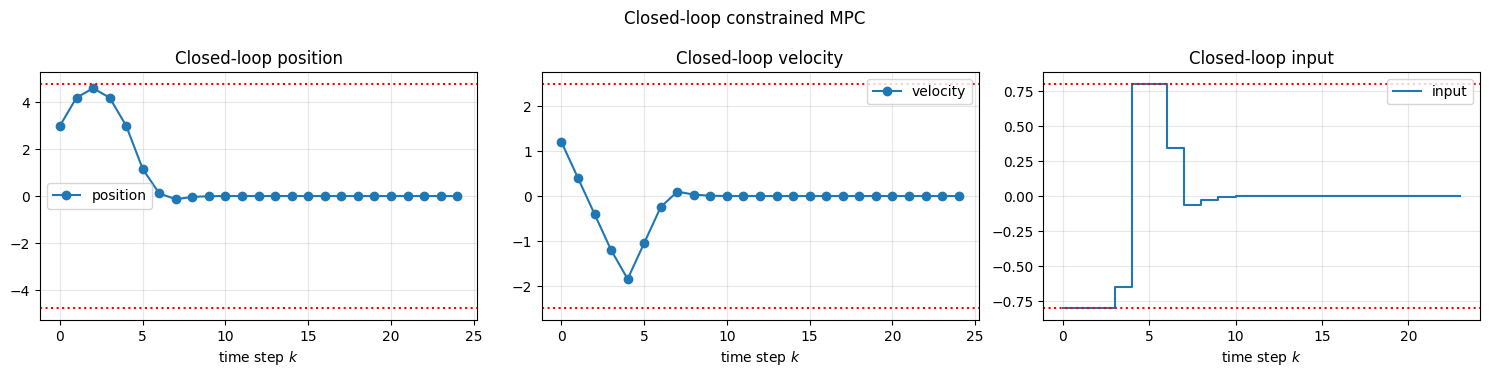

In [10]:
sim_steps = 24
X_mpc = np.zeros((sim_steps + 1, nx))
U_mpc = np.zeros((sim_steps, nu))

X_mpc[0] = np.array([3.0, 1.2])

for k in range(sim_steps):
    U_plan, X_plan, _ = solve_mpc_once(X_mpc[k])

    # Receding-horizon principle: apply only the first input.
    U_mpc[k] = U_plan[0]
    X_mpc[k + 1] = A @ X_mpc[k] + B @ U_mpc[k]

plot_closed_loop(X_mpc, U_mpc, x_max, v_max, u_max, "Closed-loop constrained MPC")

## 9) Comparison: LQR, saturated LQR, constrained MPC

LQR solves the unconstrained infinite-horizon problem.  
Saturated LQR clips the input after the fact.  
MPC builds the constraints into the optimization problem.

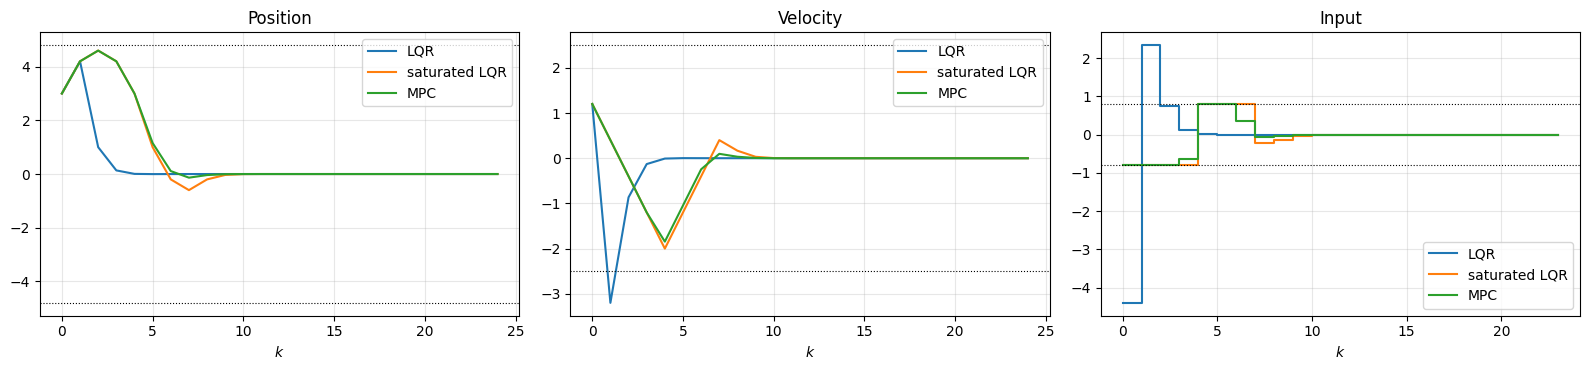

In [11]:
X_lqr = np.zeros_like(X_mpc)
U_lqr = np.zeros_like(U_mpc)
X_sat = np.zeros_like(X_mpc)
U_sat = np.zeros_like(U_mpc)

X_lqr[0] = X_mpc[0]
X_sat[0] = X_mpc[0]

for k in range(sim_steps):
    u_lqr = float(-(K_inf @ X_lqr[k]).item())
    u_sat = np.clip(float(-(K_inf @ X_sat[k]).item()), -u_max, u_max)

    U_lqr[k, 0] = u_lqr
    U_sat[k, 0] = u_sat

    X_lqr[k + 1] = A @ X_lqr[k] + B[:, 0] * u_lqr
    X_sat[k + 1] = A @ X_sat[k] + B[:, 0] * u_sat

results = {
    "LQR": (X_lqr, U_lqr),
    "saturated LQR": (X_sat, U_sat),
    "MPC": (X_mpc, U_mpc),
}

plot_controller_comparison(results, x_max, v_max, u_max)

## 10) Tuning as approximation engineering

We keep the same implementation and modify only the design parameters:

- horizon length $N$,
- state weight $Q$,
- input weight $R$.

Each choice changes how the finite-horizon problem approximates the remaining cost-to-go.

Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optimal point
Polishing not needed - no active set detected at optima

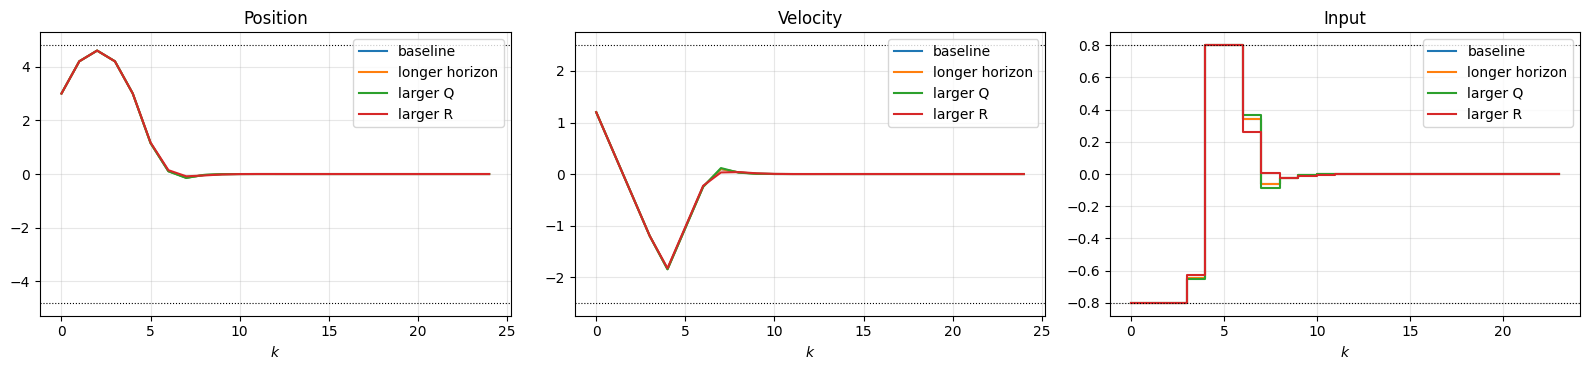

In [12]:
tuning_cases = [
    ("baseline", 10, Q, R),
    ("longer horizon", 16, Q, R),
    ("larger Q", 10, 3.0 * Q, R),
    ("larger R", 10, Q, 5.0 * R),
]

tuning_results = {}

for label, N_case, Q_case, R_case in tuning_cases:
    P_case = solve_discrete_are(A, B, Q_case, R_case)

    X_case = np.zeros((sim_steps + 1, nx))
    U_case = np.zeros((sim_steps, nu))
    X_case[0] = X_mpc[0]

    for k in range(sim_steps):
        U_plan, _, _ = solve_mpc_once(X_case[k], N=N_case, Q=Q_case, R=R_case, P_f=P_case)
        U_case[k] = U_plan[0]
        X_case[k + 1] = A @ X_case[k] + B @ U_case[k]

    tuning_results[label] = (X_case, U_case)

plot_controller_comparison(tuning_results, x_max, v_max, u_max)